# Pitt Corpus — Cookie Theft Task: Control vs Dementia

Acoustic feature analysis using **openSMILE eGeMAPS v02** (88 functionals).

- **Control**: `Pitt/control/cookie/` — 243 recordings, 99 participants  
- **Dementia**: `Pitt/dementia/cookie/` — 309 recordings, 194 participants  

Each recording is a participant's verbal description of the Cookie Theft picture (Boston Diagnostic Aphasia Examination).

In [1]:
import os, glob, warnings, contextlib, io, tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import librosa
import librosa.display
import opensmile
import soundfile as sf
from scipy.stats import mannwhitneyu
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

## 1. Load Pitt Cookie Audio Files

In [2]:
import glob

PITT_CONTROL_DIR  = "Pitt/control/cookie"
PITT_DEMENTIA_DIR = "Pitt/dementia/cookie"

def list_pitt_files(folder, label):
    files = sorted(glob.glob(os.path.join(folder, "*.mp3")))
    rows = []
    for fp in files:
        fname = os.path.splitext(os.path.basename(fp))[0]  # e.g. "002-0"
        parts = fname.split("-")
        pid   = int(parts[0])
        visit = int(parts[1]) if len(parts) > 1 else 0
        rows.append({"pid": pid, "visit": visit, "group": label, "path": fp})
    return rows

control_rows  = list_pitt_files(PITT_CONTROL_DIR,  "Control")
dementia_rows = list_pitt_files(PITT_DEMENTIA_DIR, "Dementia")

pitt_meta = pd.DataFrame(control_rows + dementia_rows)

print(f"Control  recordings : {len(control_rows)}")
print(f"Dementia recordings : {len(dementia_rows)}")
print(f"Total               : {len(pitt_meta)}")
print(f"\nUnique Control  participants: {pitt_meta[pitt_meta.group=='Control' ]['pid'].nunique()}")
print(f"Unique Dementia participants: {pitt_meta[pitt_meta.group=='Dementia']['pid'].nunique()}")
pitt_meta.groupby("group")["visit"].value_counts().unstack(fill_value=0)

Control  recordings : 243
Dementia recordings : 309
Total               : 552

Unique Control  participants: 99
Unique Dementia participants: 194


visit,0,1,2,3,4
group,,,,,
Control,71,67,53,36,16
Dementia,170,77,39,17,6


## 2. Extract eGeMAPS Features

Extracts all 88 eGeMAPS v02 functionals per recording. Audio is force-converted to mono before processing.

In [4]:
from tqdm.notebook import tqdm

# Initialise openSMILE with eGeMAPS v02 functionals
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

pitt_feat_rows = []

for _, row in tqdm(pitt_meta.iterrows(), total=len(pitt_meta), desc="Extracting features"):
    try:
        # Force mono via librosa → temp wav → openSMILE
        y, sr = librosa.load(row["path"], sr=None, mono=True)
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
            tmp_path = tmp.name
        sf.write(tmp_path, y, sr, subtype="PCM_16")

        with contextlib.redirect_stderr(io.StringIO()):
            feats = smile.process_file(tmp_path)
        os.unlink(tmp_path)

        feat_row = feats.iloc[0].to_dict()
        feat_row["pid"]      = row["pid"]
        feat_row["visit"]    = row["visit"]
        feat_row["group"]    = row["group"]
        feat_row["duration"] = len(y) / sr
        pitt_feat_rows.append(feat_row)

    except Exception as e:
        print(f"  SKIP {row['path']}: {e}")

pitt_feat_df = pd.DataFrame(pitt_feat_rows)
print(f"\nExtracted: {len(pitt_feat_df)} recordings")
print(pitt_feat_df.groupby("group")[["duration"]].describe().round(1))

Extracting features:   0%|          | 0/552 [00:00<?, ?it/s]


Extracted: 552 recordings
         duration                                           
            count  mean   std   min   25%   50%   75%    max
group                                                       
Control     243.0  62.7  24.2  17.9  45.8  58.5  76.6  168.6
Dementia    309.0  75.7  35.0  23.6  53.3  69.9  89.5  268.5


## 2b. Join PItt Metadata & Resolve Diagnoses

Cross-reference audio files with `PItt-data.xlsx` to get clean labels, MMSE scores, age, sex and education.

**basedx codes:**
- `8` = Control (healthy)
- `1` = Probable AD
- `2` = Possible AD
- `6` = Vascular dementia / other cognitive impairment (normal cognition suspected)
- `5` = MCI / depression (cognitively normal at baseline)
- `3/4` = Other dementia
- `7` = Unknown

In [8]:

# ── Load PItt-data.xlsx ────────────────────────────────────────────────────────
pitt_dx = pd.read_excel("PItt-data.xlsx", sheet_name="data", header=2)

# Keep only columns we need
pitt_dx = pitt_dx[["id", "basedx", "groupdx", "sex", "entryage", "educ", "mms", "cdrfs", "lastdx"]].copy()
pitt_dx.rename(columns={"id": "pid", "entryage": "age"}, inplace=True)

# ── basedx → clean label ───────────────────────────────────────────────────────
# Folder "dementia/" contains codes: 1=probAD, 2=possAD, 3=other, 4=other,
#   5=MCI/depression, 6=vascular/other, 7=unknown
# Folder "control/" contains only code 8

DEFINITE_AD   = {1, 2}          # probable + possible AD  → keep as Dementia
CONTROL_CODE  = {8}             # healthy controls
AMBIGUOUS     = {5, 6}          # MCI, depression, vascular → "Unknown"
OTHER_DEMENTIA = {3, 4}         # other dementias → keep as Dementia

def resolve_label(row):
    code = row["basedx"]
    if code in CONTROL_CODE:
        return "Control"
    elif code in DEFINITE_AD or code in OTHER_DEMENTIA:
        return "Dementia"
    else:
        return "Unknown"   # codes 5, 6, 7

pitt_dx["dx_label"] = pitt_dx.apply(resolve_label, axis=1)

print("=== Resolved labels (all 510 rows in spreadsheet) ===")
print(pitt_dx["dx_label"].value_counts())

# ── Merge with pitt_feat_df ────────────────────────────────────────────────────
pitt_feat_df = pitt_feat_df.merge(
    pitt_dx[["pid","basedx","sex","age","educ","mms","cdrfs","dx_label"]],
    on="pid", how="left"
)

# ── Diagnose mismatch: folder label vs spreadsheet label ──────────────────────
mismatch = pitt_feat_df[pitt_feat_df["group"] != pitt_feat_df["dx_label"]]
print(f"\nFolder vs spreadsheet label mismatches: {len(mismatch)}")
print(mismatch[["pid","group","basedx","dx_label","mms"]].value_counts(
    ["group","dx_label","basedx"]).reset_index().to_string(index=False))

# ── Deduplication: keep only visit=0 per participant ──────────────────────────
pitt_baseline = (
    pitt_feat_df
    .sort_values("visit")
    .groupby(["pid","group"], as_index=False)
    .first()
)
print(f"\n── Baseline-only (visit=0) dataset ──────────────────────────────")
print(f"Total recordings : {len(pitt_baseline)}")
print(pitt_baseline.groupby("group")[["age","mms"]].describe().round(1))

# ── Clean binary dataset: Control vs Dementia only (exclude Unknown) ──────────
pitt_clean = pitt_baseline[pitt_baseline["dx_label"].isin(["Control","Dementia"])].copy()
print(f"\n── Clean binary dataset (Control vs Dementia, baseline only) ────")
print(pitt_clean["dx_label"].value_counts())
print(f"\nAge  — Control: {pitt_clean[pitt_clean.dx_label=='Control' ]['age'].mean():.1f}  "
      f"Dementia: {pitt_clean[pitt_clean.dx_label=='Dementia']['age'].mean():.1f}")
print(f"MMSE — Control: {pitt_clean[pitt_clean.dx_label=='Control' ]['mms'].mean():.1f}  "
      f"Dementia: {pitt_clean[pitt_clean.dx_label=='Dementia']['mms'].mean():.1f}")


=== Resolved labels (all 510 rows in spreadsheet) ===
dx_label
Dementia    353
Control     121
Unknown      36
Name: count, dtype: int64

Folder vs spreadsheet label mismatches: 48
   group dx_label  basedx  count
Dementia  Unknown       6     33
Dementia  Unknown       5     11
Dementia  Control       8      3
Dementia  Unknown       7      1

── Baseline-only (visit=0) dataset ──────────────────────────────
Total recordings : 293
            age                                             mms             \
          count  mean  std   min   25%   50%   75%   max  count  mean  std   
group                                                                        
Control    99.0  63.7  7.9  46.0  58.0  65.0  70.0  80.0   99.0  29.1  1.1   
Dementia  194.0  71.0  8.6  49.0  65.0  72.0  78.0  88.0  194.0  20.2  5.2   

                                        
           min   25%   50%   75%   max  
group                                   
Control   26.0  28.0  29.0  30.0  30.0  
Dementia 

## 3. Recording Duration Distribution

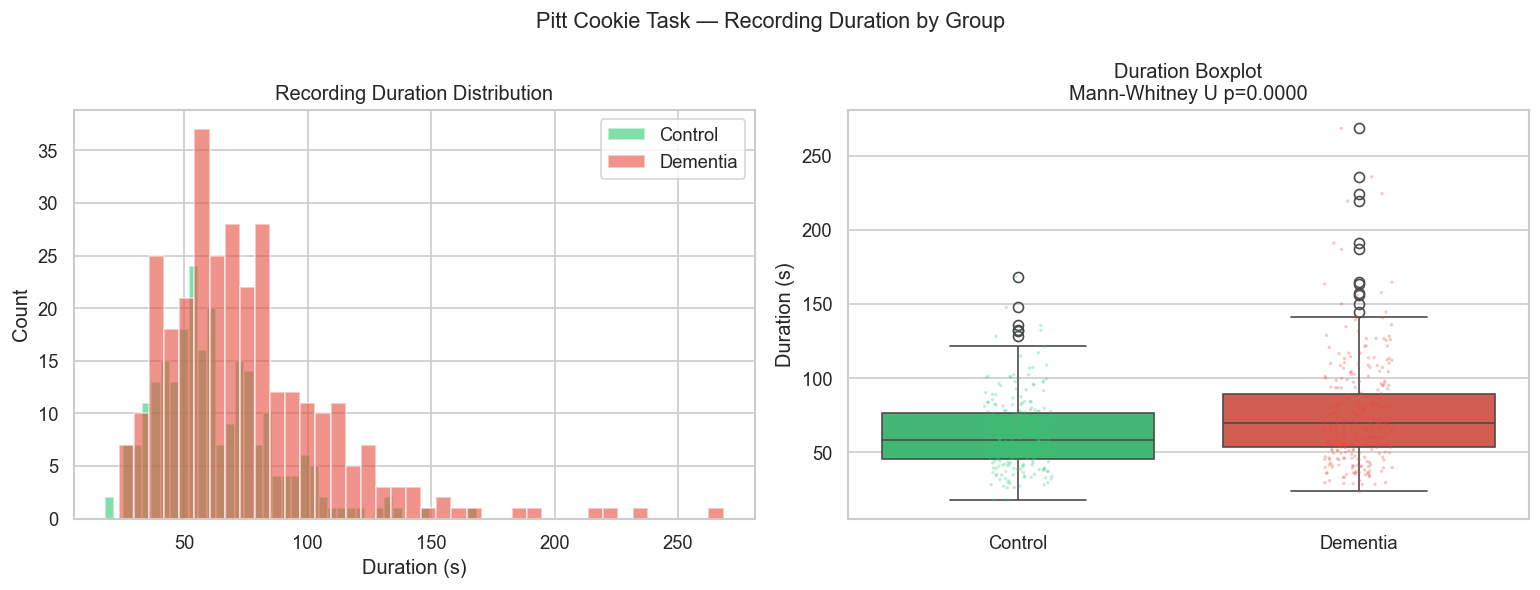


Control  — mean: 62.7s  median: 58.5s
Dementia — mean: 75.7s  median: 69.9s


In [5]:
from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {"Control": "#2ecc71", "Dementia": "#e74c3c"}

# Histogram
for grp, grp_df in pitt_feat_df.groupby("group"):
    axes[0].hist(grp_df["duration"], bins=40, alpha=0.6,
                 label=grp, color=palette[grp], edgecolor="white")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Recording Duration Distribution")
axes[0].legend()

# Boxplot
sns.boxplot(data=pitt_feat_df, x="group", y="duration",
            palette=palette, ax=axes[1], order=["Control", "Dementia"])
sns.stripplot(data=pitt_feat_df, x="group", y="duration",
              palette=palette, ax=axes[1], order=["Control", "Dementia"],
              size=2, alpha=0.3, jitter=True)
axes[1].set_title("Duration Boxplot")
axes[1].set_xlabel("")
axes[1].set_ylabel("Duration (s)")

# Mann-Whitney U test
ctrl_dur = pitt_feat_df[pitt_feat_df.group=="Control"]["duration"]
dem_dur  = pitt_feat_df[pitt_feat_df.group=="Dementia"]["duration"]
u_stat, p_val = mannwhitneyu(ctrl_dur, dem_dur, alternative="two-sided")
axes[1].set_title(f"Duration Boxplot\nMann-Whitney U p={p_val:.4f}")

plt.suptitle("Pitt Cookie Task — Recording Duration by Group", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nControl  — mean: {ctrl_dur.mean():.1f}s  median: {ctrl_dur.median():.1f}s")
print(f"Dementia — mean: {dem_dur.mean():.1f}s  median: {dem_dur.median():.1f}s")

## 4. Key eGeMAPS Features

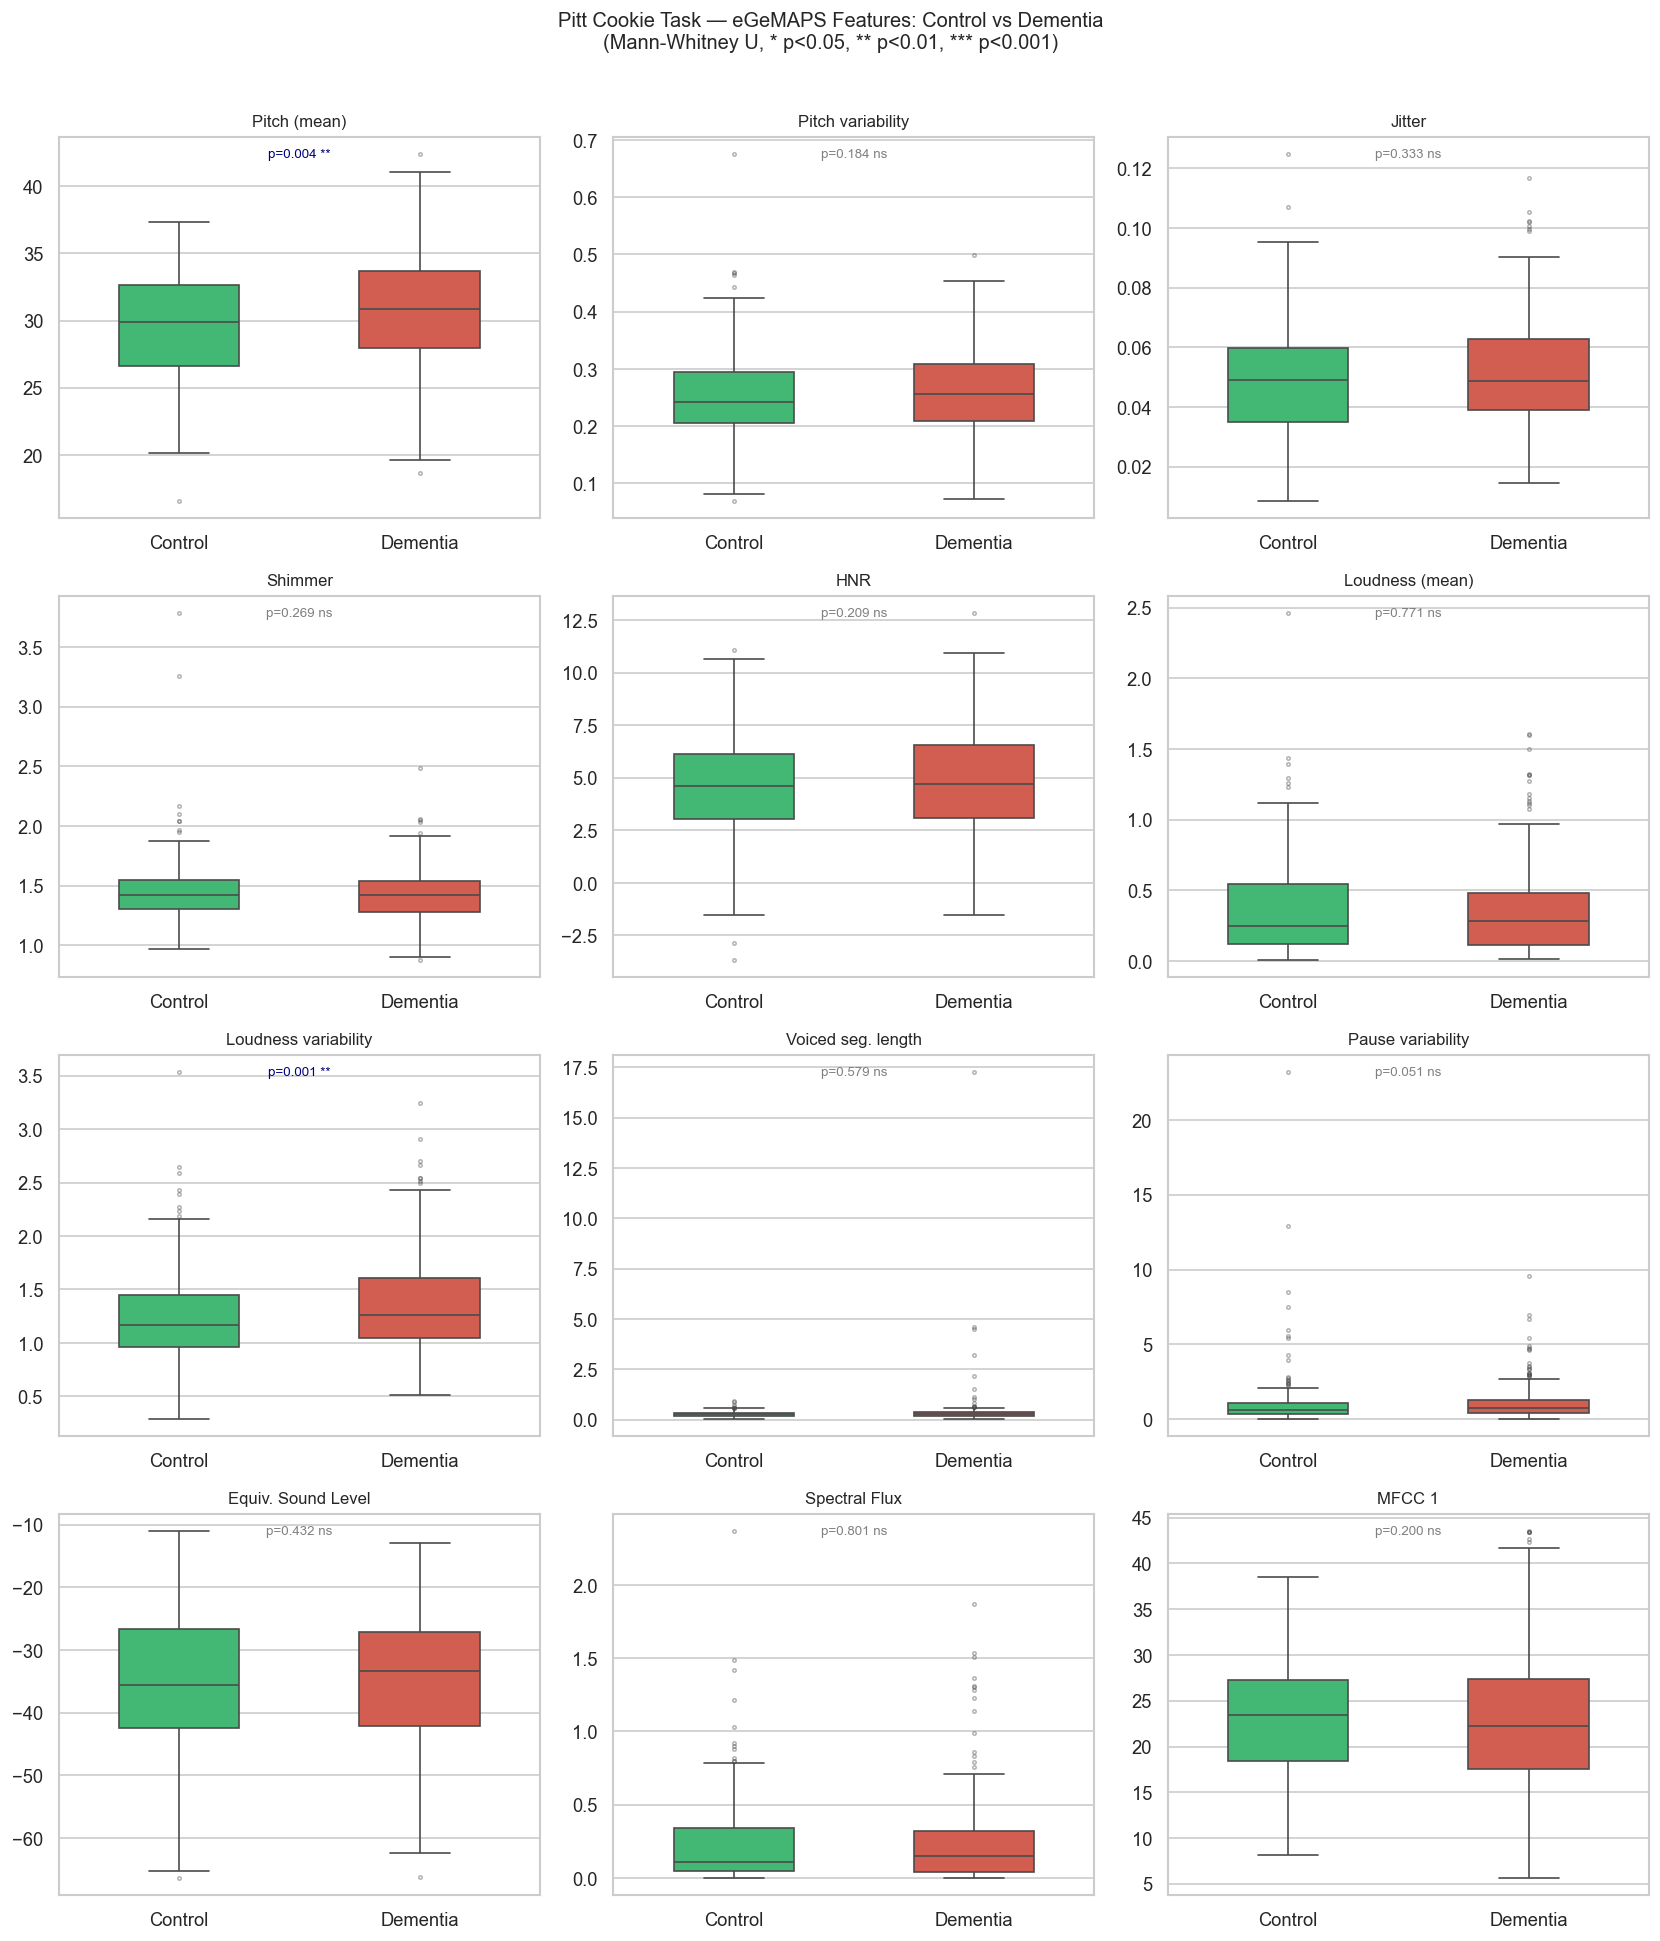

In [6]:
PITT_KEY_FEATURES = [
    ("F0semitoneFrom27.5Hz_sma3nz_amean",     "Pitch (mean)"),
    ("F0semitoneFrom27.5Hz_sma3nz_stddevNorm","Pitch variability"),
    ("jitterLocal_sma3nz_amean",              "Jitter"),
    ("shimmerLocaldB_sma3nz_amean",           "Shimmer"),
    ("HNRdBACF_sma3nz_amean",                 "HNR"),
    ("loudness_sma3_amean",                   "Loudness (mean)"),
    ("loudness_sma3_stddevNorm",              "Loudness variability"),
    ("MeanVoicedSegmentLengthSec",            "Voiced seg. length"),
    ("StddevUnvoicedSegmentLength",           "Pause variability"),
    ("equivalentSoundLevel_dBp",              "Equiv. Sound Level"),
    ("spectralFlux_sma3_amean",               "Spectral Flux"),
    ("mfcc1_sma3_amean",                      "MFCC 1"),
]

# Filter to features present in data
pitt_key = [(f, lbl) for f, lbl in PITT_KEY_FEATURES if f in pitt_feat_df.columns]

ncols = 3
nrows = -(-len(pitt_key) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for idx, (feat, label) in enumerate(pitt_key):
    ax = axes[idx]
    sns.boxplot(data=pitt_feat_df, x="group", y=feat,
                palette=palette, ax=ax, order=["Control", "Dementia"],
                width=0.5, flierprops=dict(markersize=2, alpha=0.4))

    # Mann-Whitney p-value annotation
    c = pitt_feat_df[pitt_feat_df.group == "Control"][feat].dropna()
    d = pitt_feat_df[pitt_feat_df.group == "Dementia"][feat].dropna()
    if len(c) > 1 and len(d) > 1:
        _, p = mannwhitneyu(c, d, alternative="two-sided")
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        y_pos = max(pitt_feat_df[feat].quantile(0.95), ax.get_ylim()[1] * 0.9)
        ax.annotate(f"p={p:.3f} {sig}", xy=(0.5, 0.97), xycoords="axes fraction",
                    ha="center", va="top", fontsize=8,
                    color="navy" if p < 0.05 else "gray")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(len(pitt_key), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Pitt Cookie Task — eGeMAPS Features: Control vs Dementia\n(Mann-Whitney U, * p<0.05, ** p<0.01, *** p<0.001)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Top Discriminating Features

Rank all 88 eGeMAPS features by Mann-Whitney U test p-value (Control vs Dementia).

Top 20 most discriminating features (Control vs Dementia):
                                      feature      p_value  effect_r   ctrl_mean    dem_mean
   F0semitoneFrom27.5Hz_sma3nz_percentile80.0 1.094769e-07  0.263121   33.635578   35.753075
     F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2 1.146941e-06  0.241040    8.664156   10.445442
                     F2frequency_sma3nz_amean 1.052646e-04  0.192164 1635.406912 1660.981413
                F2frequency_sma3nz_stddevNorm 2.523468e-04 -0.181350    0.180857    0.175097
                     F1frequency_sma3nz_amean 6.235018e-04  0.169523  613.815305  631.613243
                         VoicedSegmentsPerSec 9.735082e-04 -0.163424    1.521520    1.394147
                     loudness_sma3_stddevNorm 1.360415e-03  0.158709    1.250135    1.371768
                     F3frequency_sma3nz_amean 2.143456e-03  0.152104 2705.036764 2730.170898
              spectralFluxV_sma3nz_stddevNorm 3.690325e-03  0.143873    0.992270    0.974685
           

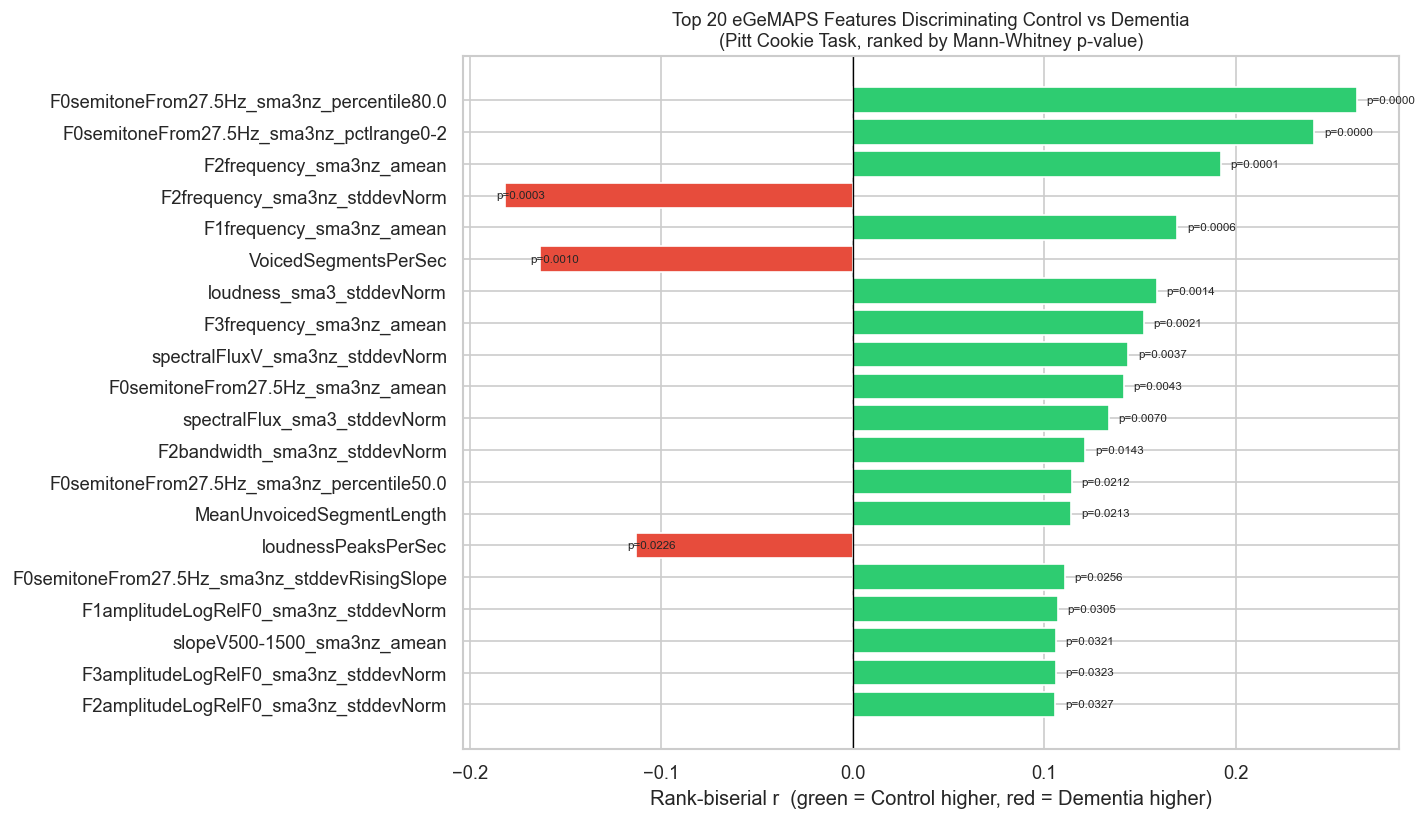

In [7]:
acoustic_pitt_cols = [c for c in pitt_feat_df.columns
                      if c not in ["pid", "visit", "group", "duration"]]

ctrl_df = pitt_feat_df[pitt_feat_df.group == "Control"]
dem_df  = pitt_feat_df[pitt_feat_df.group == "Dementia"]

mw_results = []
for col in acoustic_pitt_cols:
    c = ctrl_df[col].dropna()
    d = dem_df[col].dropna()
    if len(c) < 2 or len(d) < 2:
        continue
    u, p = mannwhitneyu(c, d, alternative="two-sided")
    # Effect size: rank-biserial correlation
    n1, n2 = len(c), len(d)
    r = 1 - (2 * u) / (n1 * n2)
    mw_results.append({
        "feature":   col,
        "p_value":   p,
        "effect_r":  r,
        "ctrl_mean": c.mean(),
        "dem_mean":  d.mean(),
    })

mw_df = (pd.DataFrame(mw_results)
           .sort_values("p_value")
           .reset_index(drop=True))

print("Top 20 most discriminating features (Control vs Dementia):")
print(mw_df.head(20)[["feature","p_value","effect_r","ctrl_mean","dem_mean"]].to_string(index=False))

# Plot top 20
top20_mw = mw_df.head(20)
colours_mw = ["#2ecc71" if r > 0 else "#e74c3c" for r in top20_mw["effect_r"]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20_mw["feature"][::-1], top20_mw["effect_r"][::-1], color=colours_mw[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Rank-biserial r  (green = Control higher, red = Dementia higher)")
ax.set_title("Top 20 eGeMAPS Features Discriminating Control vs Dementia\n(Pitt Cookie Task, ranked by Mann-Whitney p-value)", fontsize=11)

for bar, (_, row) in zip(bars, top20_mw[::-1].iterrows()):
    ax.text(bar.get_width() + 0.005 * np.sign(bar.get_width()) if bar.get_width() != 0 else 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"p={row['p_value']:.4f}", va="center", fontsize=7)

plt.tight_layout()
plt.show()